# End-to-End Machine Learning Pipeline on Tesla Sales/Price Data

This notebook contains:

- Data Loading
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Model Evaluation
- Time Series Forecasting
- Future Predictions


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


((2640, 12), None)

## Exploratory Data Analysis

In [4]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


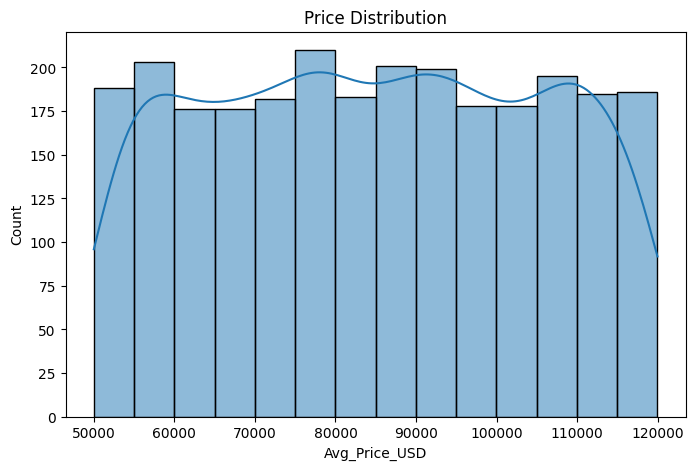

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Price_USD'], kde=True)
plt.title('Price Distribution')
plt.show()


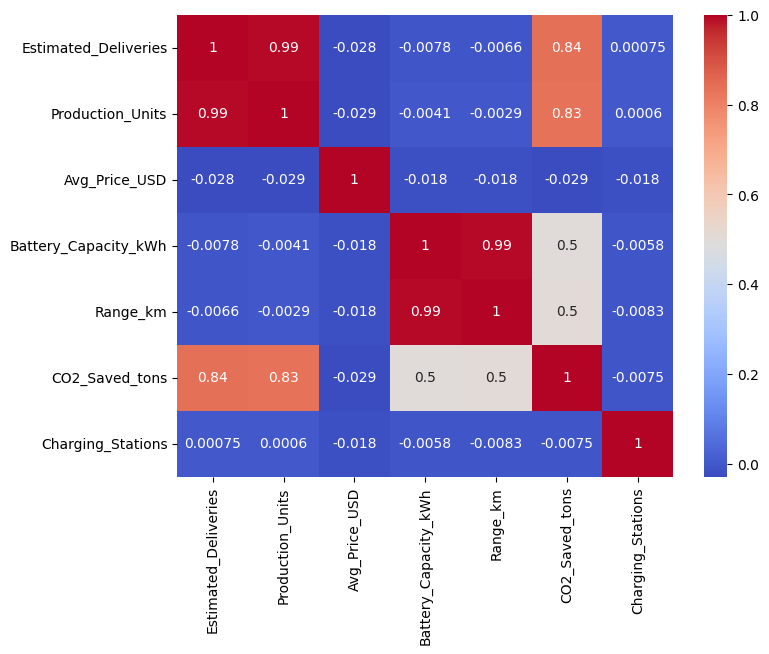

In [6]:
corr_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
             'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']

plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.show()


## Feature Engineering

In [7]:
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))

df['Delivery_Production_Ratio'] = (
    df['Estimated_Deliveries'] / df['Production_Units']
)

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Delivery_Production_Ratio
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,0.984600
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,0.911864
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,0.915334
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,0.896594
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,0.914087


## Regression Model: Predict Tesla Average Price

In [8]:
X = df.drop(columns=['Avg_Price_USD','Date'])
y = df['Avg_Price_USD']

categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [9]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2  :", r2_score(y_test, preds))


MAE : 17164.890420454547
RMSE: 20064.93639100081
R2  : -0.06758969959885253


## Hyperparameter Tuning

In [10]:
param_grid = {
    'regressor__n_estimators':[100,200],
    'regressor__max_depth':[10,20,None]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score :", grid.best_score_)


Best Parameters: {'regressor__max_depth': 10, 'regressor__n_estimators': 200}
Best CV Score : -0.01743661595616053


## Time Series Forecasting (Monthly Deliveries)

In [11]:
monthly = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()

monthly.head()


,Date,Estimated_Deliveries
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264


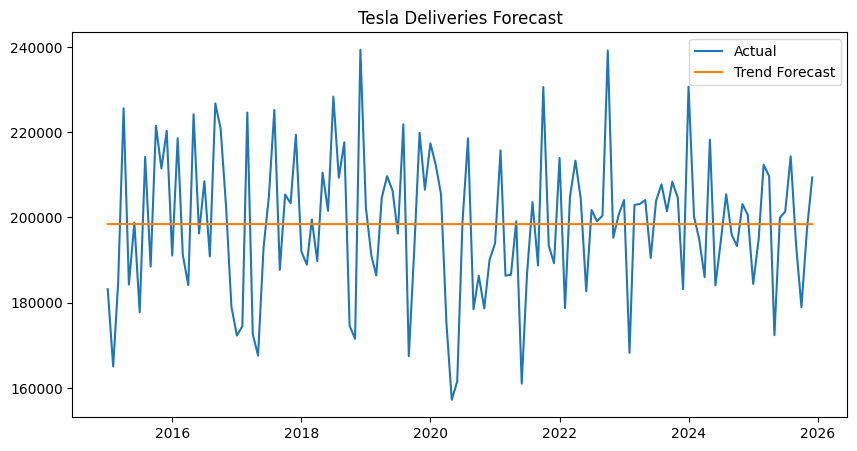

In [12]:
from sklearn.linear_model import LinearRegression

monthly['Time_Index'] = np.arange(len(monthly))

ts_model = LinearRegression()
ts_model.fit(monthly[['Time_Index']], monthly['Estimated_Deliveries'])

monthly['Forecast'] = ts_model.predict(monthly[['Time_Index']])

plt.figure(figsize=(10,5))
plt.plot(monthly['Date'], monthly['Estimated_Deliveries'], label='Actual')
plt.plot(monthly['Date'], monthly['Forecast'], label='Trend Forecast')
plt.legend()
plt.title('Tesla Deliveries Forecast')
plt.show()


In [13]:
future = pd.DataFrame({
    'Time_Index': np.arange(
        len(monthly),
        len(monthly)+12
    )
})

future['Forecast_Deliveries'] = ts_model.predict(future[['Time_Index']])

future


,Time_Index,Forecast_Deliveries
0,132,198436.571015
1,133,198436.459415
2,134,198436.347815
3,135,198436.236215
4,136,198436.124615
5,137,198436.013015
6,138,198435.901415
7,139,198435.789815
8,140,198435.678214
9,141,198435.566614
